In [33]:
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

In [28]:
# GET BTC

url = "https://api.binance.com/api/v3/klines"
params = {
    "symbol" : "BTCUSDT", # symbol
    "interval" : "1d", # last limit days , here limit = 24 so it's the 24 last days
    "limit" : 365 # number of candle
}

response_btc = requests.get(url,params=params)


In [29]:
# GET ETH


url = "https://api.binance.com/api/v3/klines"
params = {
    "symbol" : "ETHUSDT", # symbol
    "interval" : "1d", # last limit days , here limit = 24 so it's the 24 last days
    "limit" : 365 # number of candle
}

response_eth = requests.get(url,params=params)

In [30]:
# PREPROCESS THE DATA (ALIGN THE DATA)

data_btc = response_btc.json()
data_eth = response_eth.json()

data_btc = pd.DataFrame(data_btc)
data_eth = pd.DataFrame(data_eth)

data_btc = data_btc.iloc[:,[0,4]]
data_btc.rename(columns={4:'Close',0:'Time'},inplace=True)

data_eth = data_eth.iloc[:,[0,4]]
data_eth.rename(columns={4:'Close',0:'Time'},inplace=True)

data_btc['Time'] = pd.to_datetime(data_btc['Time'],unit='ms')
data_eth['Time'] = pd.to_datetime(data_eth['Time'],unit='ms')

data_btc.set_index(keys='Time',inplace=True)
data_eth.set_index(keys='Time',inplace=True)

data = pd.DataFrame({
    'CLOSE_BTC' : data_btc['Close'].astype(float),
    'CLOSE_ETH' : data_eth['Close'].astype(float)
})

print(data.dtypes)

CLOSE_BTC    float64
CLOSE_ETH    float64
dtype: object


In [31]:
# LOG RETURN 
data['LOG_RETURN_BTC'] = np.log(data['CLOSE_BTC'] / data['CLOSE_BTC'].shift(1))
data['LOG_RETURN_ETH'] = np.log(data['CLOSE_ETH'] / data['CLOSE_ETH'].shift(1))
data = data.dropna()
print(data)

            CLOSE_BTC  CLOSE_ETH  LOG_RETURN_BTC  LOG_RETURN_ETH
Time                                                            
2025-06-01  105642.93    2539.21        0.009999        0.004401
2025-06-02  105857.99    2607.41        0.002034        0.026504
2025-06-03  105376.89    2593.36       -0.004555       -0.005403
2025-06-04  104696.86    2607.68       -0.006474        0.005507
2025-06-05  101508.68    2414.01       -0.030925       -0.077172
...               ...        ...             ...             ...
2026-05-26   75930.01    2073.77       -0.018167       -0.018745
2026-05-27   74449.30    2024.84       -0.019694       -0.023878
2026-05-28   73617.51    2009.90       -0.011235       -0.007406
2026-05-29   73460.78    2014.54       -0.002131        0.002306
2026-05-30   73617.12    2016.90        0.002126        0.001171

[364 rows x 4 columns]


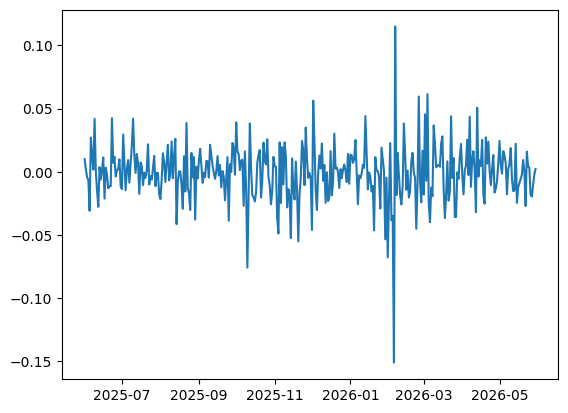

In [32]:
plt.plot(data['LOG_RETURN_BTC'])

In [35]:
result_btc = adfuller(data['LOG_RETURN_BTC'])
print("p-value BTC niveau:", result_btc[1])

result_eth = adfuller(data['LOG_RETURN_ETH'])
print("p-value ETH niveau:", result_eth[1])

p-value BTC niveau: 0.0
p-value ETH niveau: 2.2734272048082808e-30


In [ ]:
data['LOG_BTC'] = np.log(data['CLOSE_BTC'])
data['LOG_ETH'] = np.log(data['CLOSE_ETH'])
print(data)